In [1]:
import torch

print(f"Using torch {torch.__version__}")
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device = {device}")

Using torch 2.13.0
Using device = mps


In [2]:
train_dir = 'data/train'
test_dir = 'data/val'

In [3]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [4]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
train_transform = transforms.Compose([
transforms.Resize((128,128)),
transforms.ToTensor(),
transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229,
0.224, 0.225))
])
test_transform = transforms.Compose([
transforms.Resize((128,128)),
transforms.ToTensor(),
transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229,
0.224, 0.225))
])

In [5]:
train_data = datasets.ImageFolder(root=train_dir,
transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir,
transform=test_transform)

In [6]:
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size,
shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size,
shuffle=False)

In [7]:
print(f'Training data contains {len(train_data)} images')
print(f'Testing data contains {len(test_data)} images')
class_names = train_data.classes
print(class_names)
class_names_idx = train_data.class_to_idx
print(class_names_idx)

Training data contains 9469 images
Testing data contains 3925 images
['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
{'n01440764': 0, 'n02102040': 1, 'n02979186': 2, 'n03000684': 3, 'n03028079': 4, 'n03394916': 5, 'n03417042': 6, 'n03425413': 7, 'n03445777': 8, 'n03888257': 9}


In [8]:
from model import CustomCNN
num_classes = len(train_data.classes)
model = CustomCNN(num_classes).to(device)

In [9]:
%pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [10]:
from torchinfo import summary

model.to(device)

summary(
    model=model,
    input_size=(32, 3, 128, 128),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
CustomCNN (CustomCNN)                    [32, 3, 128, 128]    [32, 10]             --                   True
├─Conv2d (conv1)                         [32, 3, 128, 128]    [32, 32, 128, 128]   896                  True
├─ReLU (relu)                            [32, 32, 128, 128]   [32, 32, 128, 128]   --                   --
├─MaxPool2d (pool)                       [32, 32, 128, 128]   [32, 32, 64, 64]     --                   --
├─Conv2d (conv2)                         [32, 32, 64, 64]     [32, 64, 64, 64]     18,496               True
├─ReLU (relu)                            [32, 64, 64, 64]     [32, 64, 64, 64]     --                   --
├─MaxPool2d (pool)                       [32, 64, 64, 64]     [32, 64, 32, 32]     --                   --
├─Conv2d (conv3)                         [32, 64, 32, 32]     [32, 128, 32, 32]    73,856               True
├─ReLU (relu)         

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [14]:
%pip install tqdm

  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
Note: you may need to restart the kernel to use updated packages.


In [15]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer 
from trainNN import train
start_time = timer()

results = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer= optimizer,
    loss_fn= criterion,
    epochs =30,
    device= device 
)

end_time = timer()
print(f"[INFO] Total training time: {end_time - start_time } seconds")

/opt/homebrew/Caskroom/miniforge/base/envs/AI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epochs:   3%|▎         | 1/30 [00:46<22:18, 46.15s/it]

Epoch: 1 | train_loss: 1.7036 | train_acc: 0.4209 | test_loss: 1.3829 | test_acc: 0.5491
[INFO] New best model saved to best_model.pth with test_acc: 0.5491


Epochs:   7%|▋         | 2/30 [01:30<20:56, 44.88s/it]

Epoch: 2 | train_loss: 1.1472 | train_acc: 0.6246 | test_loss: 1.0951 | test_acc: 0.6447
[INFO] New best model saved to best_model.pth with test_acc: 0.6447


Epochs:  10%|█         | 3/30 [02:12<19:40, 43.73s/it]

...

Epoch: 28 | train_loss: 0.0842 | train_acc: 0.9763 | test_loss: 2.7204 | test_acc: 0.6266


Epochs:  97%|█████████▋| 29/30 [22:04<00:45, 45.10s/it]

Epoch: 29 | train_loss: 0.0434 | train_acc: 0.9859 | test_loss: 2.7317 | test_acc: 0.6415


Epochs: 100%|██████████| 30/30 [22:51<00:00, 45.70s/it]

Epoch: 30 | train_loss: 0.0542 | train_acc: 0.9847 | test_loss: 2.9278 | test_acc: 0.6296
[INFO] Total training time: 1371.113789500203 seconds


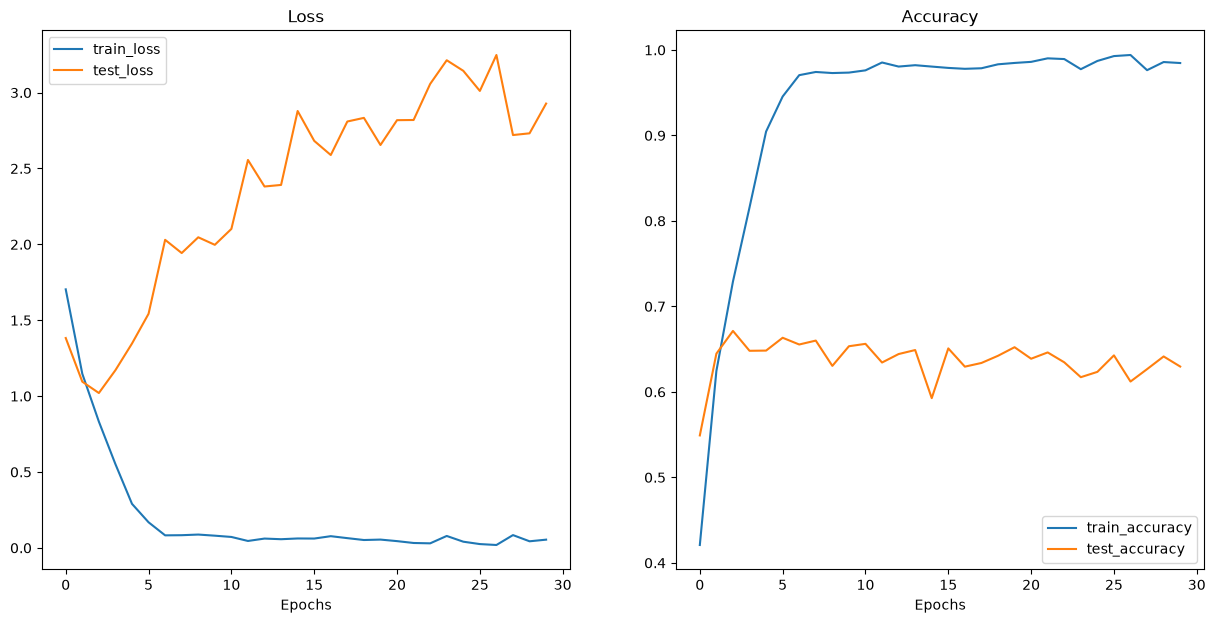

In [16]:
from helper_functions import plot_loss_curves
plot_loss_curves(results)